In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
df = pd.read_csv('Airbnb_Open_Data.csv')
df = df.drop(columns=['house_rules', 'country code', 'country', 'license', 'Construction year'])
df.set_index('id', inplace=True)
# Remove the '$' sign and convert the price column to float
df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)
# Removing missing values from lat and long
df = df.dropna(subset=['lat', 'long'])
df.rename(columns={df.columns[df.columns.str.strip() == 'service fee'][0]: 'service_fee'}, inplace=True)
df['service_fee'] = df['service_fee'].replace('[\$,]', '', regex=True).astype(float)
# First, let's ensure the columns are properly formatted
df['number of reviews'] = pd.to_numeric(df['number of reviews'], errors='coerce')
df['review rate number'] = pd.to_numeric(df['review rate number'], errors='coerce')
# Create a score column that combines review count and rating
max_reviews = df['number of reviews'].max()
df['score'] = (df['number of reviews'] / max_reviews * 0.5 + df['review rate number'] / 5 * 0.5) * 100
df['score'] = df['score'].round(2)
df['score'] = df['score'].fillna(0)

<>:5: SyntaxWarning: invalid escape sequence '\$'
<>:9: SyntaxWarning: invalid escape sequence '\$'
<>:5: SyntaxWarning: invalid escape sequence '\$'
<>:9: SyntaxWarning: invalid escape sequence '\$'
C:\Users\liaba\AppData\Local\Temp\ipykernel_21948\840571937.py:5: SyntaxWarning: invalid escape sequence '\$'
  df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)
C:\Users\liaba\AppData\Local\Temp\ipykernel_21948\840571937.py:9: SyntaxWarning: invalid escape sequence '\$'
  df['service_fee'] = df['service_fee'].replace('[\$,]', '', regex=True).astype(float)
C:\Users\liaba\AppData\Local\Temp\ipykernel_21948\840571937.py:1: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Airbnb_Open_Data.csv')


In [33]:
df.head()

,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,instant_bookable,cancellation_policy,...,price,service_fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,score
id,,,,,,,,,,,,,,,,,,,,,
1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,False,strict,...,966.0,193.0,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,40.44
1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,False,moderate,...,142.0,28.0,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,42.20
1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,True,flexible,...,620.0,124.0,3.0,0.0,NaN,NaN,5.0,1.0,352.0,50.00
1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,True,moderate,...,368.0,74.0,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,53.18
1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,False,moderate,...,204.0,41.0,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,30.44


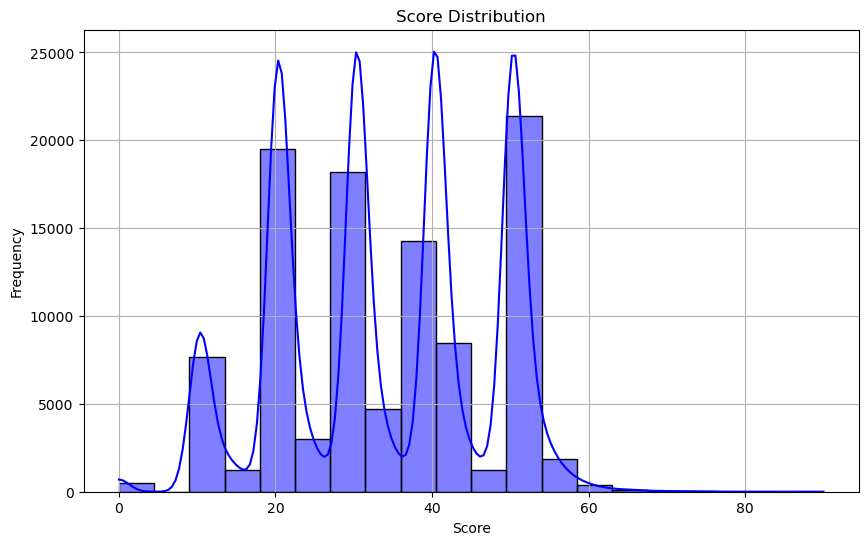

In [34]:
# Plot score distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['score'], bins=20, kde=True, color='blue')
plt.title('Score Distribution')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.grid()
plt.show()